# 03 — CGM metrics engine

Compute per-patient-visit glycemic metrics from the cleaned CGM trace,
using tested functions from src/metrics.py. Metric definitions live in
docs/metric-changelog.md — this notebook applies them, it doesn't redefine them.


## Setup


In [16]:
import sys
from pathlib import Path
sys.path.append(str(Path("../src").resolve()))
import pandas as pd
from metrics import mean_glucose, std_glucose, cv_glucose, tir_glucose, gmi_glucose, mage_glucose, excursion_count

table_a_clean = pd.read_parquet("../data/interim/table_a_clean.parquet")

## 1. Apply metrics per patient-visit

One row per (subject, visit) in the output — mean, SD, %CV, TIR, GMI, MAGE,
excursion count.


In [19]:
#groupby(["subject", "visit"]) + apply each metric function, assemble into one summary DataFrame


def summarize(group):
    return pd.Series({
        "mean" : mean_glucose(group),
        "std" : std_glucose(group),
        "cv" : cv_glucose(group),
        "tir" : tir_glucose(group),
        "gmi" : gmi_glucose(group),
        "mage" : mage_glucose(group),
        "excursion" : excursion_count(group)
    })

summarize_table_a = table_a_clean.groupby(["subject", "visit"]).apply(summarize)

print(summarize_table_a)

                     mean        std         cv        tir       gmi  \
subject visit                                                          
1001    0      196.829179  50.141982  25.474872  38.297872  8.018154   
1002    0      136.019620  59.896546  44.035225  74.789030  6.563589   
        1      115.771061  54.863485  47.389637  64.951768  6.079244   
        2      119.082353  39.667880  33.311300  77.310924  6.158450   
1003    0      151.023898  63.615561  42.122844  67.289022  6.922492   
...                   ...        ...        ...        ...       ...   
2095    0      219.969752  71.347336  32.435067  31.226486  8.571676   
2096    0      146.878916  34.808971  23.699093  80.271084  6.823344   
2097    0      172.103964  42.107588  24.466367  59.536275  7.426727   
2098    0      144.351849  29.763433  20.618671  88.301887  6.762896   
2099    0      101.452822  25.822164  25.452386  93.303236  5.736751   

                     mage  excursion  
subject visit           

## 2. Sanity check

Before trusting the full table: pick one subject-visit, compute its metrics
by hand (or spot-check against the raw trace/plot), confirm the function's
output matches.


### spot-check cell

In [ ]:
one_visit = table_a_clean[(table_a_clean["subject"] == 2035) & (table_a_clean["visit"] == 0)]
print(summarize_table_a.loc[(2035, 0)])

real = one_visit["cgm_mg_dl"].dropna()
check_tir = real.between(70, 180).mean() * 100
print("check tir: ", check_tir)



mean         119.244534
std           25.950311
cv            21.762265
tir           96.761134
gmi            6.162329
mage          44.100000
excursion     11.000000
Name: (2035, 0), dtype: float64
96.76113360323887


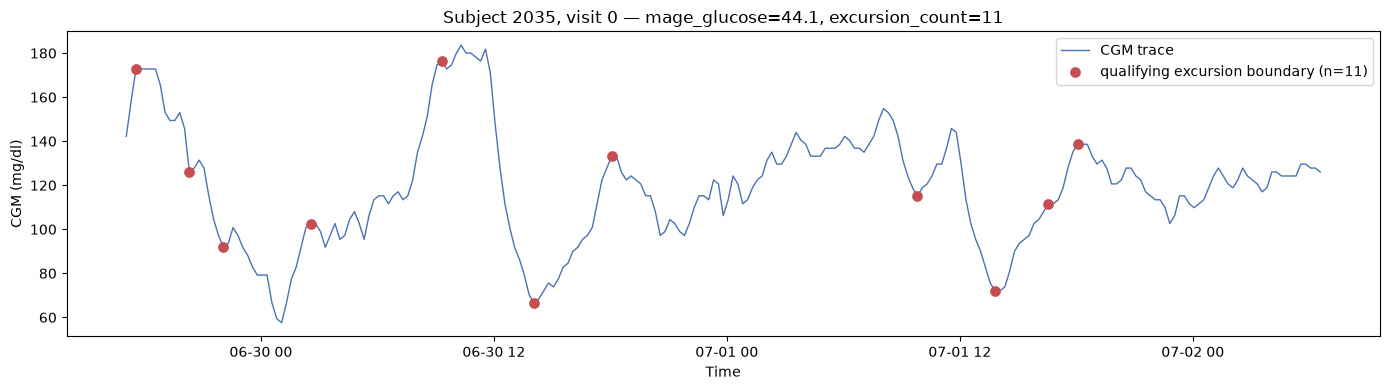

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from metrics import qualifying_swings

# Visual check for mage/excursion_count, the two most algorithmically complex
# metrics. mage_glucose/excursion_count above are still the source of truth
# for the actual numbers -- this cell only recomputes turning-point *locations*
# (not a new value for the metric itself) so they can be marked on the chart.
real = one_visit["cgm_mg_dl"].dropna()
diffs_sign = np.sign(real.diff())
turning_point = diffs_sign != diffs_sign.shift(-1)
turning_point.iloc[0] = True
turning_point.iloc[-1] = True
tp_values = real[turning_point]

qualifying = qualifying_swings(one_visit)          # same swings mage_glucose/excursion_count use
qualifying_points = tp_values.loc[qualifying.index]  # turning points where a qualifying swing lands

visit_summary = summarize_table_a.loc[(2035, 0)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one_visit["date"], one_visit["cgm_mg_dl"], color="#4C72B0", linewidth=1, label="CGM trace")
ax.scatter(
    one_visit.loc[qualifying_points.index, "date"], qualifying_points,
    color="#C44E52", zorder=5, s=45,
    label=f"qualifying excursion boundary (n={len(qualifying)})",
)
ax.set_title(
    f"Subject 2035, visit 0 — mage_glucose={visit_summary['mage']:.1f}, "
    f"excursion_count={visit_summary['excursion']:.0f}"
)
ax.set_xlabel("Time")
ax.set_ylabel("CGM (mg/dl)")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Save patient-level metric table


In [28]:
summarize_table_a.reset_index().to_parquet("../data/processed/summarize_table_a.parquet", index=False)